# Lexical of 20th century Odyssey translations (Part A)
____________________________________________________
## **Road Map**

**I. Libraries, files, and paths**

**II. The Texts**

1. Bibliographic information about the translators  
2. The translators at a glance tokenwise   

**III. TTR Analysis**

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

**IV. Zipf's Law**

**V. TF-IDF**



**VI. Discussing Results**

In [1]:
# ----------------------------------------------------------------------
# Baic Libraries
# ----------------------------------------------------------------------
import sys 
import os

import ast
from collections import Counter

import re
import nltk

import numpy as np
import pandas as pd

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

import scipy.stats as stats
from itertools import combinations

In [2]:
# ----------------------------------------------------------------------
# Personalized Visualization & Functions
# ----------------------------------------------------------------------

sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_chroma as chroma # My Vizualization library
import e_plots as oz      # My custom plots library
import e_pandisplay as pan# My pandas display options

import e_nlp_ody as e     # Import my nlp functions

import warnings           # Nononsense provision
warnings.filterwarnings('ignore')


* Got some chroma in your soma, Oma!
	 »----> use chroma.save_figure(fig, 'my_plot')
Default output path: ./Homer_xplots/

* OZ is behind the curtain!
	 »----> use oz.<func>
	 »----> also, oz goes chroma (for styling)!

*Has Pan taken over?
✓ Pandas display set to e_pandisplay defaults!
	 »----> use pan.<func>

* The editor is in the house!
	 »----> use e.<func> e.g. nlp = e.NLPPipeline(language='english')

Stopwords customized:
  Added: {'he', 'eight', 'seven', 'mrs', 'it', 'two', 'said', 'there', 'ten', "'", 'are', 'be', 'they', "'and", 'she', 'them', 'of', 'five', 'that', 'was', 'this', 'nine', 'is', 'being', 'n', 'one', 'were', 'six', 'upon', 'three', 'four', 'been', 'mr'}
  Removed: {''}
  Total stopwords: 215
Punctuation customized:
  Keeping: {'-', ''}
  Additional removals: {'-', ',\n        "\'",\n        ', '…', '—', "'", '\\'}
  Punctuation to be removed: !"#$%&'()*+,,
        "'",
        -./:;<=>?@[\]^_`{|}~—…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# ----------------------------------------------------------------------
# File management
# ----------------------------------------------------------------------

# TO UPDATE
nb_id = "lexical_A01"

output_path = f"./"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"./{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)
chroma.set_output_path(output_path_plots)

Output path set to: ././/lexical_A01_plots/


In [4]:
# ----------------------------------------------------------------------
# Odysseys
# ----------------------------------------------------------------------

translators = ['AT_Murray', 'Fitzgerald', 'Lattimore', 'Fagles', 'Wilson', 'Green', 'Woolf']

dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
df = df[['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
df["diff"] = df["num_words"] - df["num_tokens"]
e.check_df(df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens', 'diff'], dtype='object') 

* Shape: (168, 7) 

* Total memory in MB: 4.066093


In [5]:
df.sample(4, random_state=1001)

,translator,book_num,text,tokens,num_words,num_tokens,diff
145,Woolf,2,"[Uncomfortable as the night, with its rocking movement, and salt smells,\n, may have been, and in one case undoubtedly was, for Mr. Pepper had\n, insufficient clothes upon his bed, the breakfast n...","[uncomfortable, night, rocking, movement, salt, smells, may, case, undoubtedly, mr, pepper, insufficient, clothes, upon, bed, breakfast, next, morning, wore, kind, beauty, voyage, begun, begun, ha...",5430,2573,2857
117,Wilson,22,"[Odysseus ripped oﬀ his rags. Now naked,\n, he leapt upon the threshold with his bow\n, and quiverfull of arrows, which he tipped\n, out in a rush before his feet, and spoke.\n, “Playtime is over....","[odysseus, ripped, oﬀ, rags, naked, leapt, upon, threshold, bow, quiverfull, arrows, tipped, rush, feet, spoke, playtime, shoot, towards, another, mark, man, hit, apollo, may, manage, aimed, deadl...",4000,1959,2041
94,Fagles,23,"[Up to the rooms the old nurse clambered, chuckling all the way,\n, to tell the queen her husband was here now, home at last.\n, Her knees bustling, feet shuffling over each other,\n, till hoverin...","[rooms, old, nurse, clambered, chuckling, way, tell, queen, husband, home, last, knees, bustling, feet, shuffling, till, hovering, mistress, head, spoke, penelope, child, wake, see, eyes, dreamed,...",3939,1900,2039
138,Green,19,"[So noble Odysseus was left behind, there in the hall,\n, with Athene’s aid contriving a plan to kill the suitors;\n, and now he addressed Telemachos with winged words, saying:\n, “Telemachos, we ...","[noble, odysseus, left, behind, hall, athene, aid, contriving, plan, kill, suitors, addressed, telemachos, winged, words, saying, telemachos, must, lay, weapons, war, inside, disarm, suitors, soot...",6366,2942,3424


____________________________________________________
## **II. The Texts**
### **1. Bibliographic information about the translators**

Here is a brief description of each translation and the baseline. The publication period of the sample spans 100 years, from 1919 to 2018. Virginia Woolf's *The Voyage Out* is taken as a baseline because her prose mixes a high register with modern prose style––here it is assumed as a representative sample of the best prose in English. 

| Author                  | Year | Period       | Span  | Verse | Publisher               | Edition | Source                | URL                                                                 | Notes | Bibliography |
|-------------------------|------|-------------|-------|-------|-------------------------|---------|------------------------|---------------------------------------------------------------------|-------|--------------|
| Augustus Taber Murray  | 1919 | Modernism   | 1910-1940 | FALSE | Harvard UP, Loeb          | 1919    | Scaife Viewer, Tufts University | [Link](https://scaife.perseus.org/library/urn:cts:greekLit:tlg0012.tlg002/) | "No more faithful translation of Homer was ever made, and its elegance matched its fidelity. Homer's formulaic epithets, phrases, and sentences were consistently rendered, and his artificial amalgam of dialects and archaic vocabulary were, as was perfectly acceptable in those days, reflected in archaic English." From the Preface to the revised 1995 edition, also in the Loeb collection.  |*Homer. The Odyssey, Vol. 1-2. Murray, A. T. (Augustus Taber), translator. London: William Heinmann; New York: G.P. Putnam's Sons, 1919.* |
| Robert Fitzgerald      | 1961 | (Ur)Postmodernism   | 1960-1979 | TRUE  | Doubleday & Company, Inc.  | Second 1963 Edition    | Internet Archive       | [Link](https://archive.org/details/homer-the-odyssey-800-bce-robert-fitzgerald-tr-1961) | "Written in very readable, American “plain style” language" (Carolyn Clark, Best American Poetry, 2020) | *Homer. The Odyssey. Fitzgerald, Robert, translator. New York: Doubleday & Company, Inc., 1961* | 
| Richmond Lattimore     | 1965 | (Ur)Postmodernism   | 1960-1979 | TRUE      |     Farrar, Straus & Giroux                    | First 1965 Edition          | Harper Collins E-Books               | NONE | "Prose-like verse translation" (Carolyn Clark, Best American Poetry, 2020). | *Homer. The Odyssey. Lattimore, Richmond, translator. New York: Doubleday & Company, Inc., 1965* | 
| Robert Fagles         | 1996 | Postmodernism | 1980-1999 | TRUE      |  Penguin                       | First 1996 Edition        | PDF SCAN               | NONE | "Fagles awareness of Homer’s grace and ongkos (body? lumpiness, even!) is such that he gives us a plausible epic, persuasive, engaging, and resonant. He deserves congratulations and thanks" (Bryn Mawr Classical Review). | *Homer. The Odyssey. Fagles, Robert, translator. University of California Press, 1996*|
| Emily Wilson          | 2017 | Contemporary | >2000 | TRUE      | W.W. Norton & Company Inc.         | First 2017 Edition | PDF SCAN  | NONE| "Emily Wilson’s crisp and musical version is a cultural landmark. Armed with a sharp, scholarly rigour, she has produced a translation that exposes centuries of masculinist readings of the poem" (Higgins, The Guardian) | *Homer. The Odyssey. Wilson, Emily, translator. W.W. Norton & Company Inc., 2017* |
| Peter Green           | 2018 | Contemporary | >2000 | TRUE | University of California Press | Digital | EBSCOhost | [Link](https://search.ebscohost.com/login.aspx?direct=true&scope=site&db=nlebk&db=nlabk&AN=1696363) | "Green’s Odyssey is unified by a flexible hexameter line … but it combines this unity with great variety of pace and tone, giving vivid but different expression to the contrasting elements that make this work so compelling in detail and wide in imaginative scope" (Prestwich, The Manchester Review). | *Homer. The Odyssey. Green, Peter, translator. University of California Press, 2018* |
| Virginia Woolf | 1915 | Modernism | 1910-1940 | FALSE | Project Gutenberg eBook | 2024 [2006] | Project Gutenberg eBook | [Link](https://www.gutenberg.org/cache/epub/144/pg144.txt) | Baseline | Woolf, V. *The Voyage Out*. Duckworth, London, 1915 |

### Use of Latin vs Greek Forms for Characters' Names by Translator

There is an interesting inconsistency in how different translators handle character names in the Odyssey. Up until Fagles, every translator used a mix of direct Greek transliteration and conventional names passed down through earlier tradition.

- **Murray:** Tends to use Greek forms (Telemakhos, Menelaos) yet more popular names (Odysseus, Athena) remain in their Latin form.

- **Fitzgerald:** Opts for transliterating Greek phonetics, like Murray's "Telemakhos" but takes this approach further with forms like "Akhilleus." However, other names still retain their popular form.

- **Lattimore:** Uses fewer Greek forms than Fitzgerald (e.g., "Telemachus" rather than "Telemakhos") but still employs "Athene" and "Achilleus."

- **Fagles:** Experiments less with character names and settles on conventional forms that would be more familiar to modern readers.

- **Wilson:** Follows the same naming conventions as Fagles, prioritizing accessibility.

- **Green:** Returns to a Greek flavor by including Greek diacritical marks in names: Achillēs, Menelaös, Tēlemachos, Athēnē.

The names of places follow the same pattern across these translations. This naming variation will be analyzed thoroughly in the Named Entity Recognition step of the project, which will allow us to quantitatively compare these stylistic choices across the different translations.

### 2. **The translators at a glance**
#### **a) Lenght and distribution**  

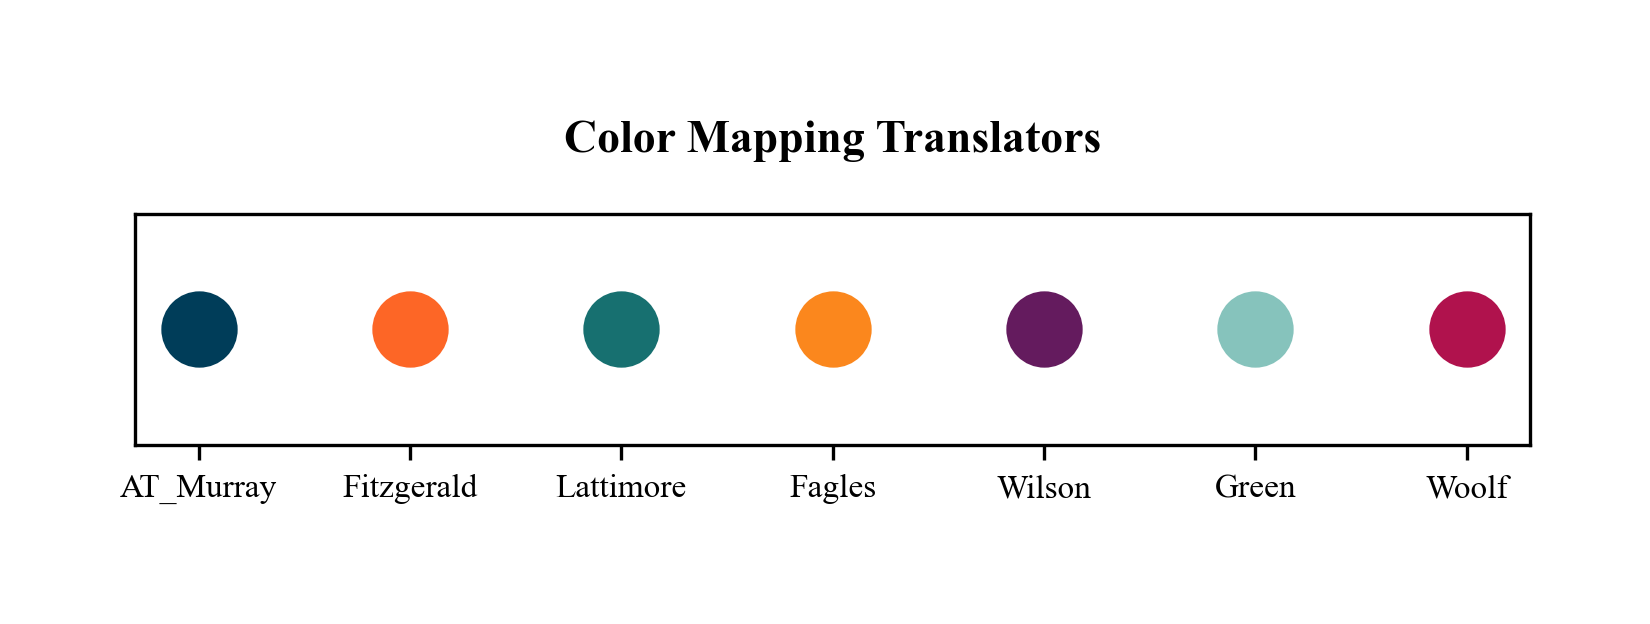

In [6]:
# ----------------------------------------------------------------------
# Create a color mapping for translators
# ----------------------------------------------------------------------

translators = df["translator"].unique()
palette = {translator: color for translator, 
           color in zip(translators, chroma.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (translator, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=300)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Color Mapping Translators", fontsize=11)
plt.savefig(f"{output_path_plots}translator_color_mapping-{nb_id}.png")
plt.show()

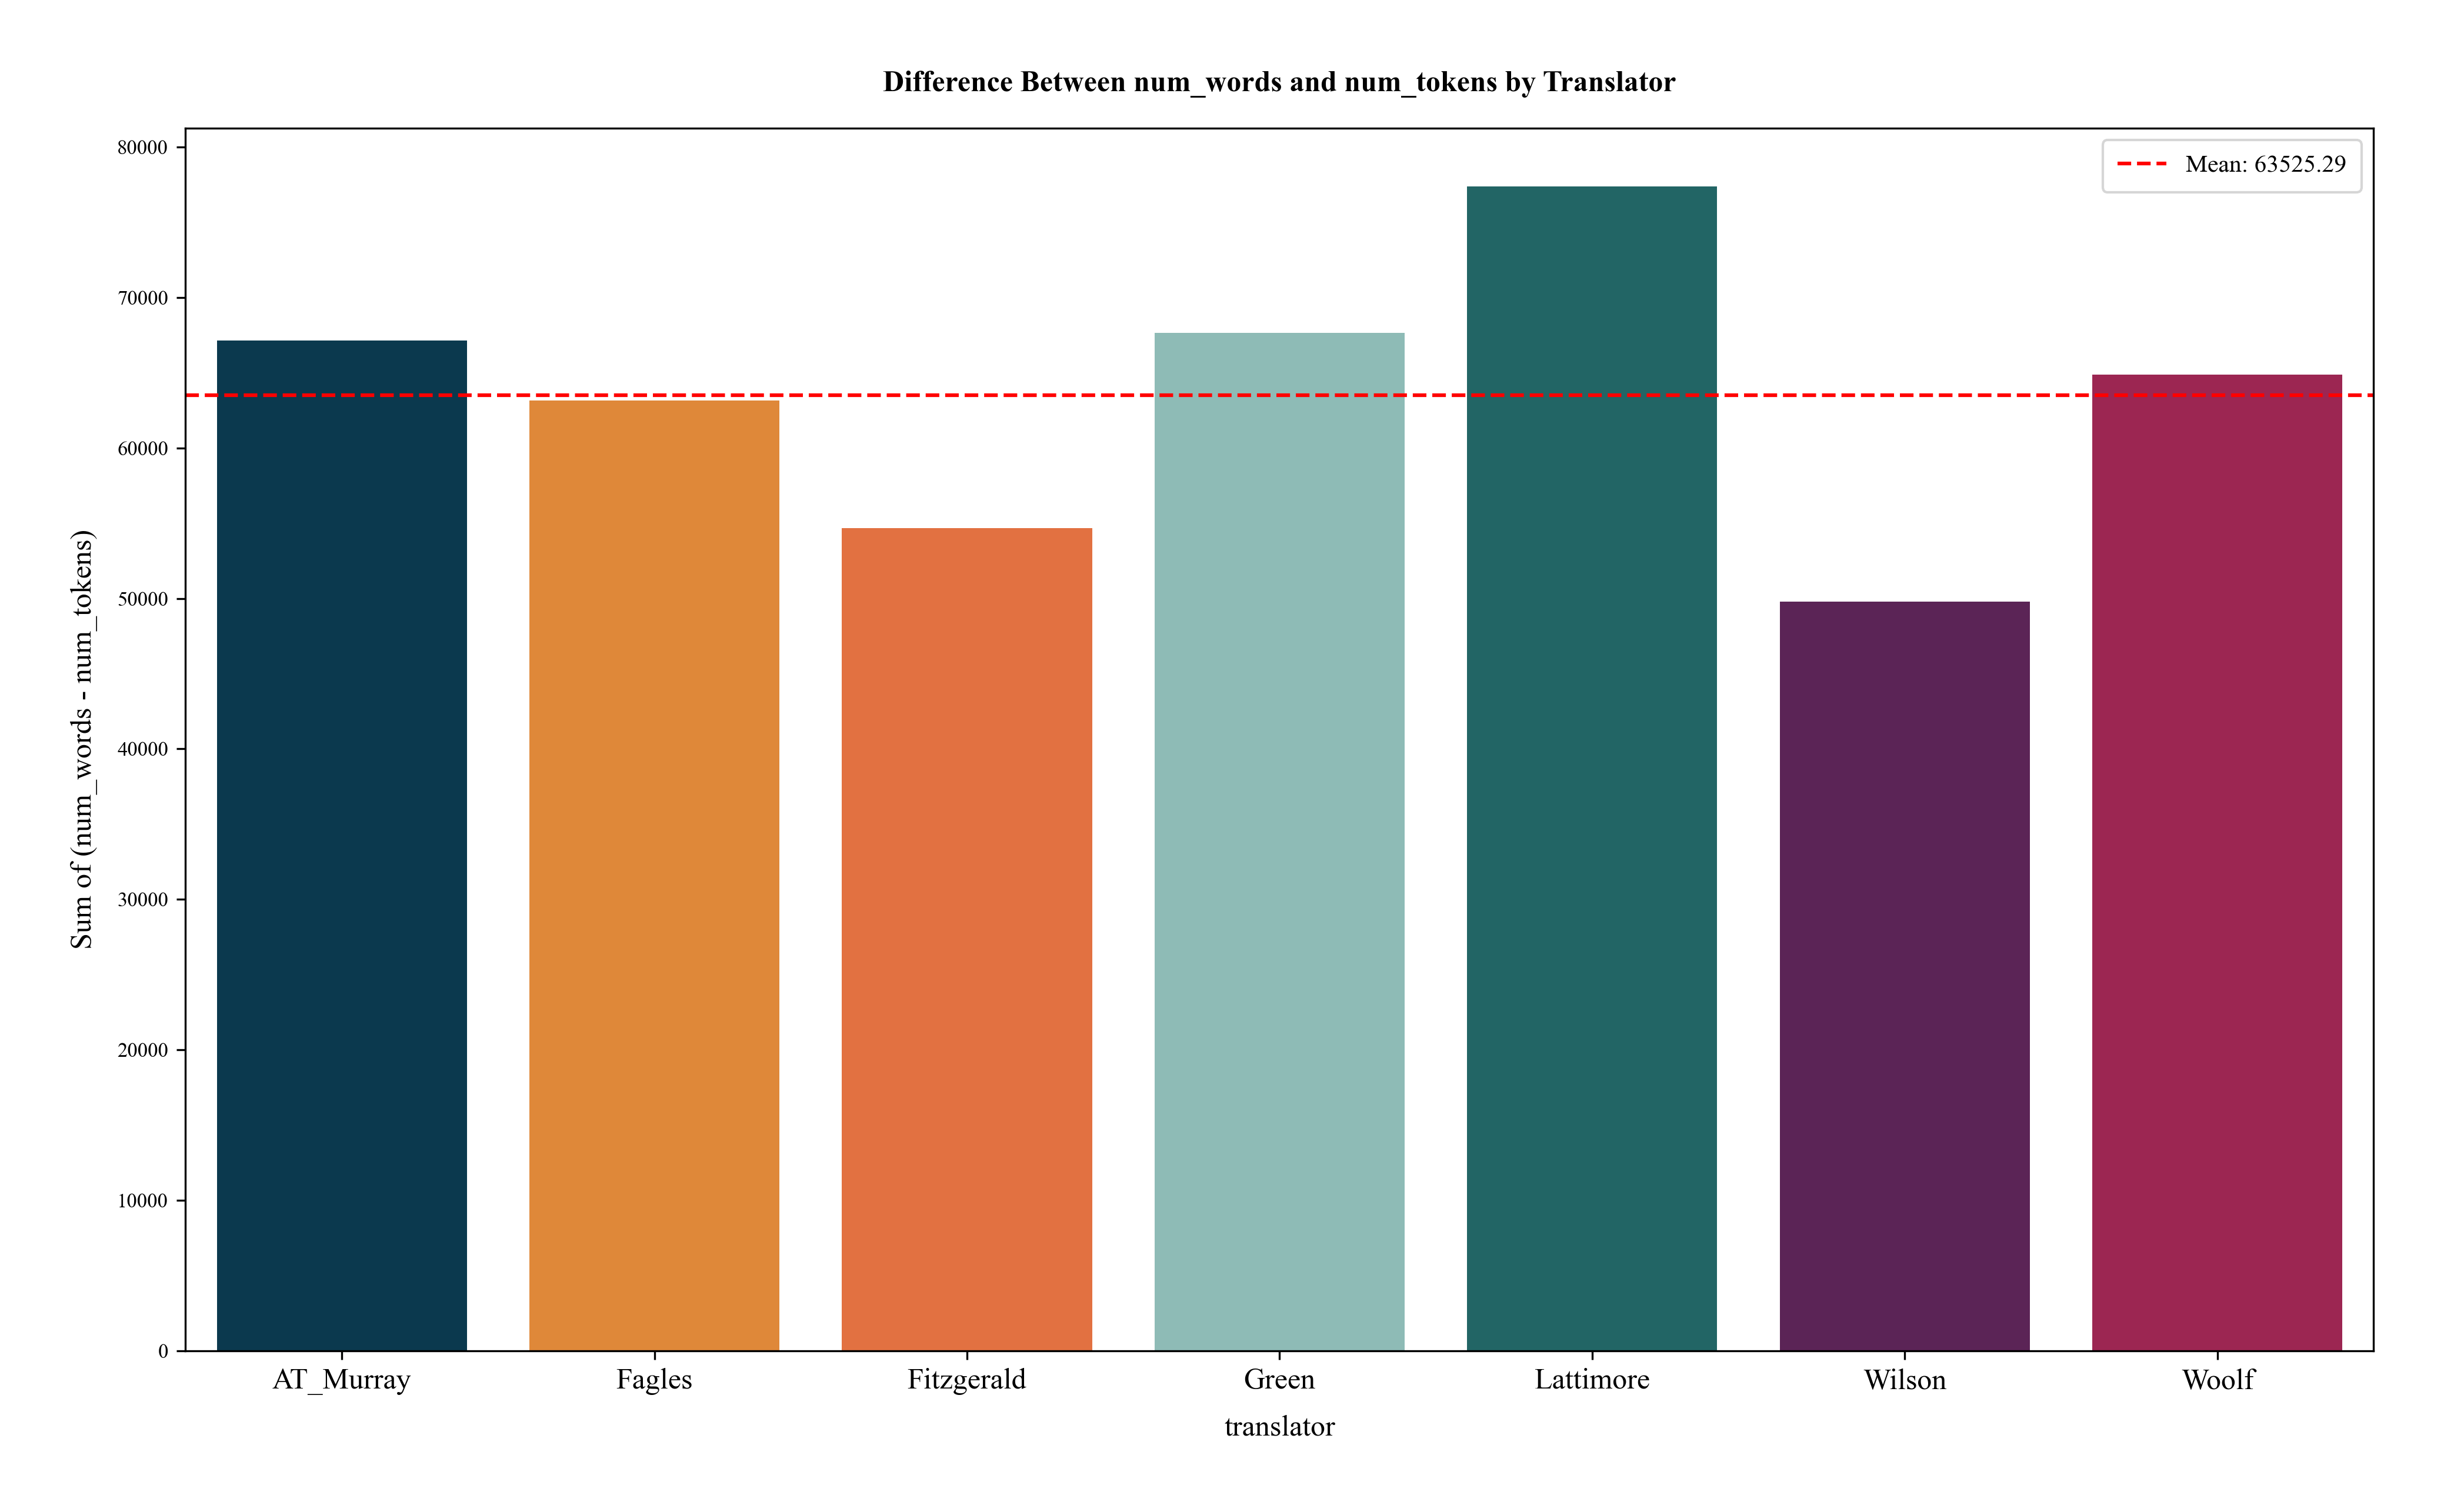

The most verbose translator is Lattimore with a difference of 77405
The most concise translator is Wilson with a difference of 49769


In [7]:
# ----------------------------------------------------------------------
# Plot differences between num_words and num_tokens
# To visualize word-to-token ratio: verbose or concise
# ----------------------------------------------------------------------

# Aggregate sum per translator
agg_diff = df.groupby("translator")["diff"].sum()
mean_agg_diff = agg_diff.mean()

# Plot
sns.barplot(data=df, x="translator", y="diff", estimator=sum, errorbar=None,
            palette=palette)  # Explicit color mapping 

# Mean horizontal line
plt.axhline(mean_agg_diff, color="red", linestyle="--",
            label=f"Mean: {mean_agg_diff:.2f}")

# Labels and title
plt.xlabel("translator")
plt.ylabel("Sum of (num_words - num_tokens)")
plt.title("Difference Between num_words and num_tokens by Translator")
plt.legend()
plt.savefig(output_path_plots + f"diff_words_tokens-{nb_id}.png")  # Save plot
plt.show()
# ----------------------------------------------------------------------
print(f"The most verbose translator is {agg_diff.idxmax()} with a difference of {agg_diff.max()}")
print(f"The most concise translator is {agg_diff.idxmin()} with a difference of {agg_diff.min()}")

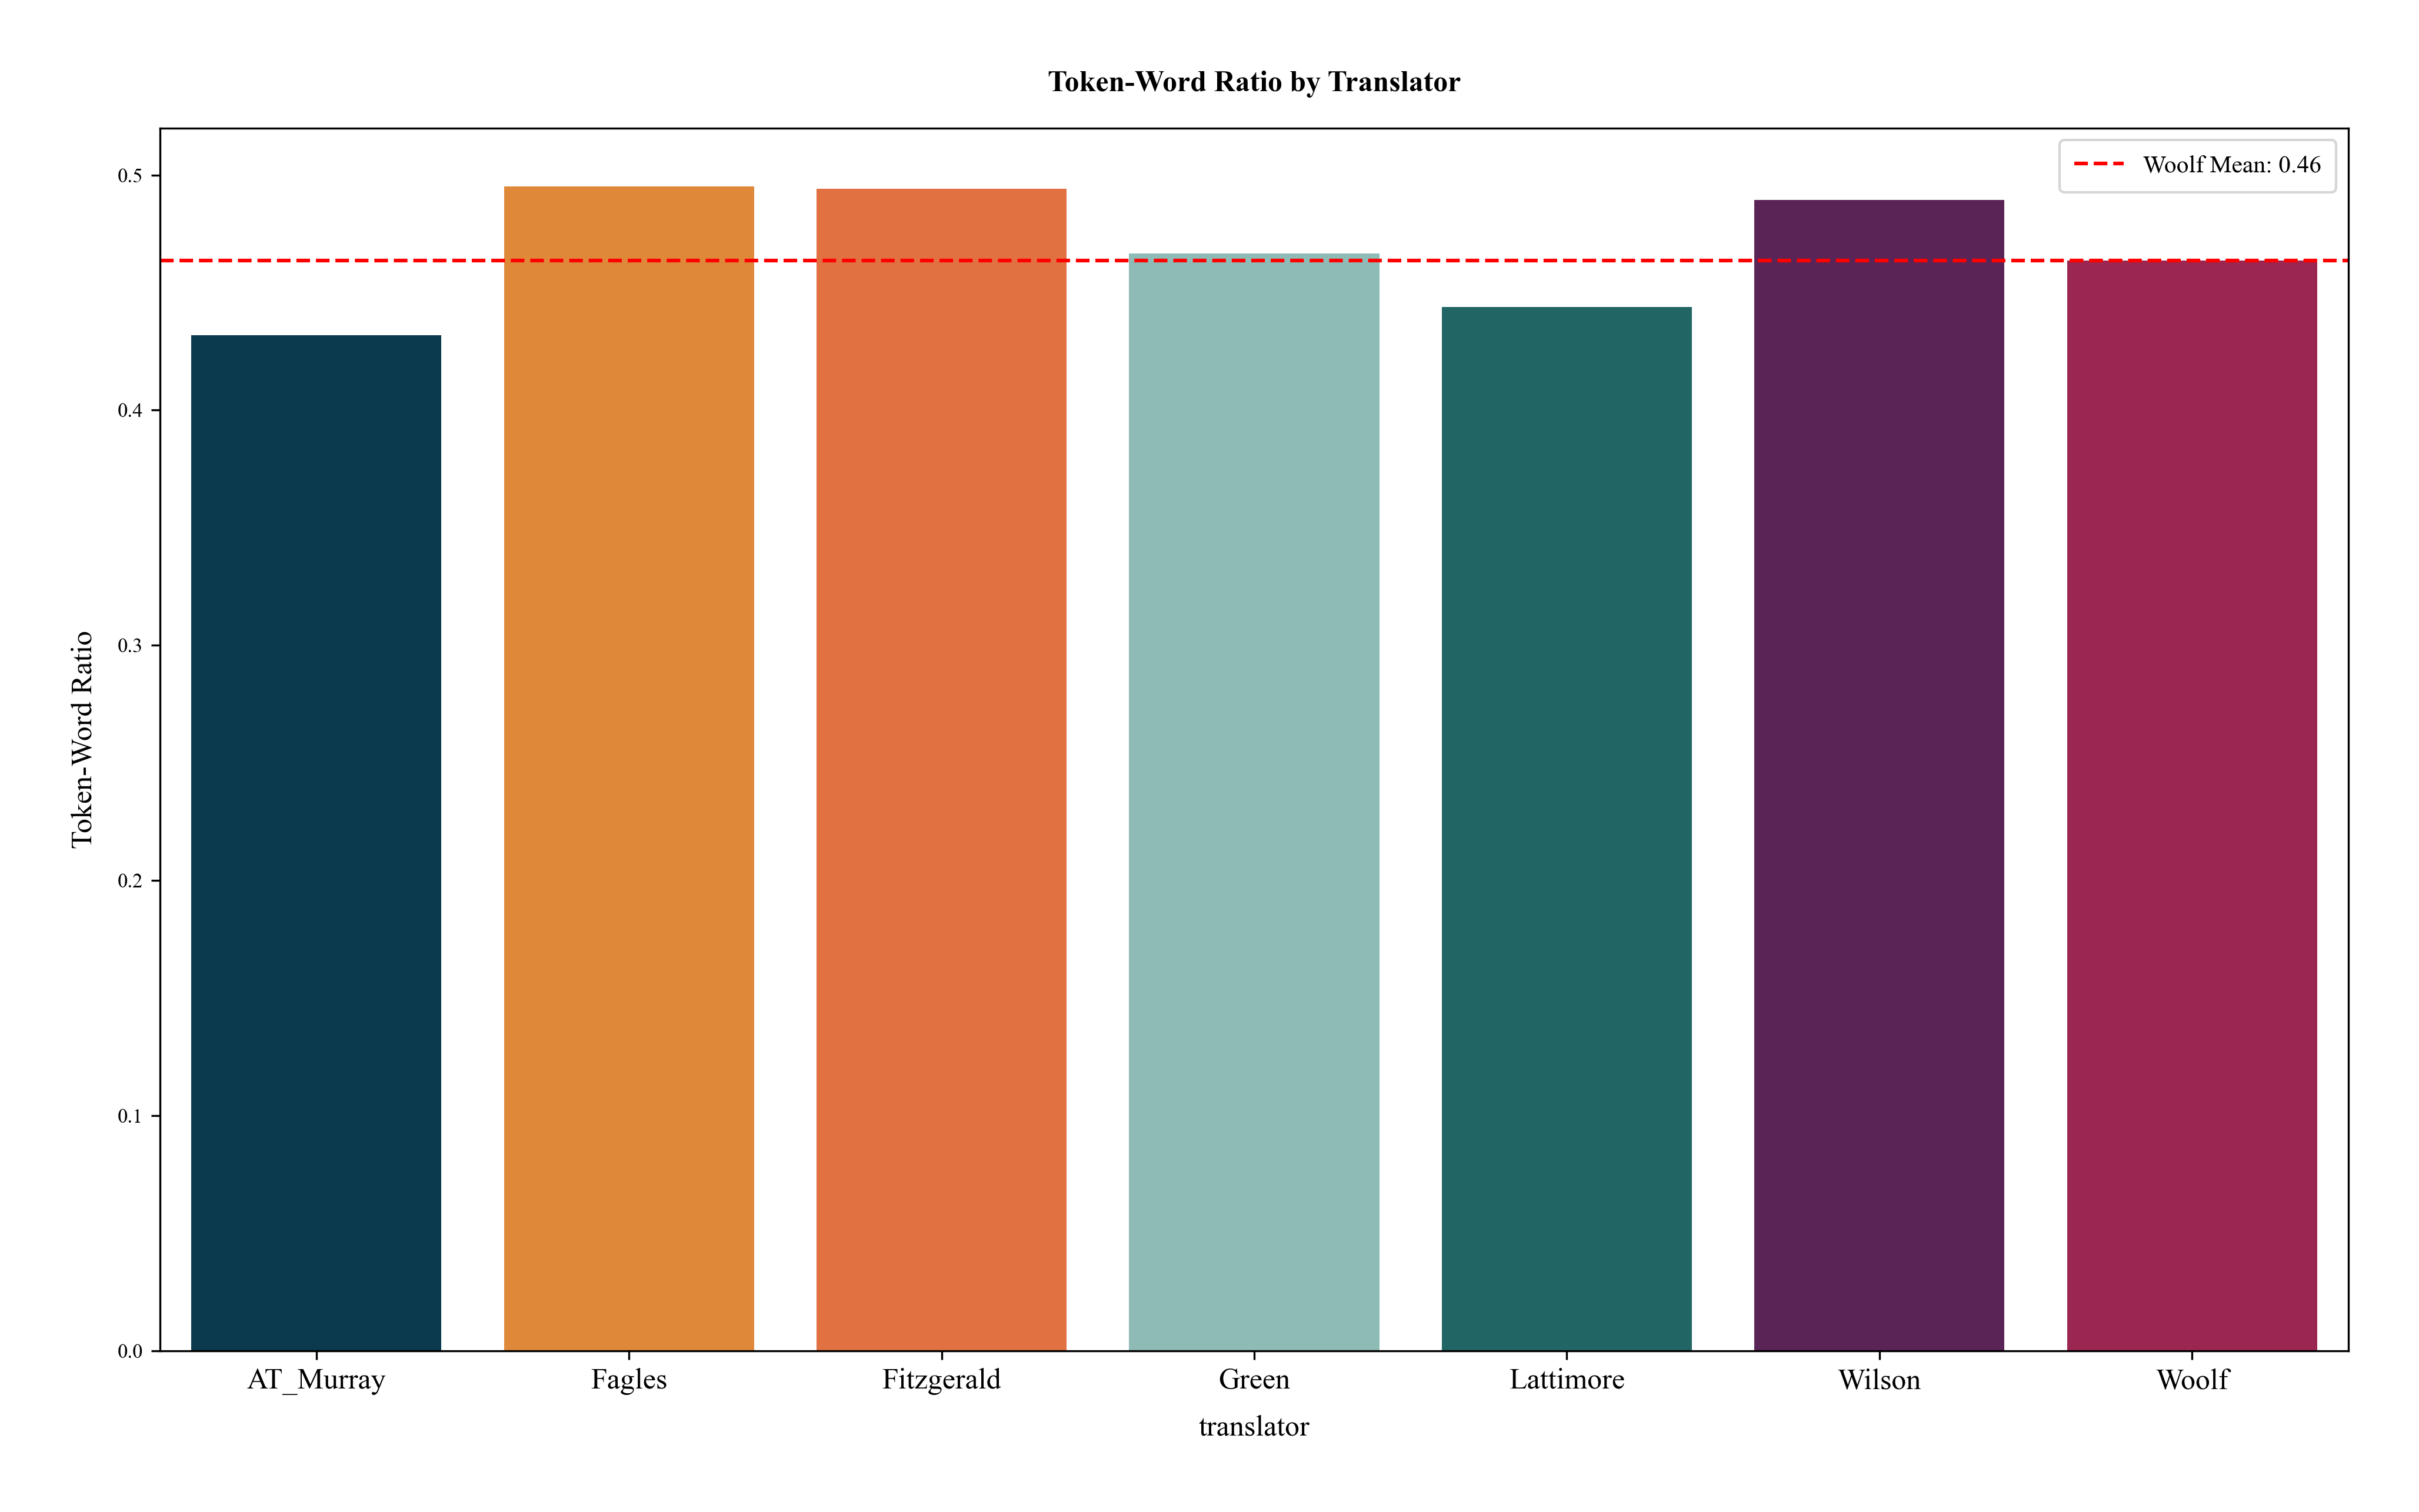

Baseline translator: Woolf with a ratio of 0.46
translator
AT_Murray    0.43
Fagles       0.50
Fitzgerald   0.49
Green        0.47
Lattimore    0.44
Wilson       0.49
Woolf        0.46
Name: token_word_ratio, dtype: float64


In [8]:
# ----------------------------------------------------------------------
# Compute mean token-word ratio per translator
# This shows translation density: higher token-word ratios indicate
# more tokens per word, suggesting more complex or elaborate language choices
# ----------------------------------------------------------------------

df["token_word_ratio"] = df["num_tokens"] / df["num_words"]

baseline_translator = "Woolf"
baseline_ratio = df[df["translator"] == baseline_translator]["token_word_ratio"].mean()

translator_means = df.groupby("translator")["token_word_ratio"].mean().reset_index()

sns.barplot(data=translator_means, x="translator", y="token_word_ratio",
             palette=palette)

# Baseline (horizontal line for reference translator)
plt.axhline(baseline_ratio, color="red", linestyle="--", 
            label=f"{baseline_translator} Mean: {baseline_ratio:.2f}")

plt.xlabel("translator")
plt.ylabel("Token-Word Ratio")
plt.title("Token-Word Ratio by Translator")
plt.xticks() 
plt.legend()
plt.savefig(output_path_plots + f"token_word_ratio-{nb_id}.png")  
plt.show()
# ----------------------------------------------------------------------
print(f"Baseline translator: {baseline_translator} with a ratio of {baseline_ratio:.2f}")
print(df.groupby("translator")["token_word_ratio"].mean())


#### **b) Token quality check**

In [9]:
# ----------------------------------------------------------------------
# First sentence extraction
# ----------------------------------------------------------------------

df['text_string'] = df['text'].apply(lambda x: "".join(x).replace("\n", "") if isinstance(x, list) else "")
df['sentences'] = df['text_string'].apply(lambda x: x.split(".") if isinstance(x, str) else [])
df['first_sentence'] = df['sentences'].apply(lambda x: x[0].strip() if len(x) > 0 else "")

# Group by 'translator' and extract the first sentence
first_sent_df = df.groupby("translator").first().reset_index()[["translator", "first_sentence"]]
pd.set_option("display.max_colwidth", 400)  # Prevent truncation of long values
first_sent_df

,translator,first_sentence
0,AT_Murray,"Tell me, O Muse, of that many-sided hero whotraveled far and wide after he had sacked the famous town of Troy"
1,Fagles,"Sing to me of the man, Muse, the man of twists and turns …driven time and again off course, once he had plunderedthe hallowed heights of Troy"
2,Fitzgerald,"Sing in me, Muse, and through me tell the story of that man skilled in all ways of contending, the wanderer, harried for years on end, after he plundered the stronghold on the proud height of Troy"
3,Green,"The man, Muse—tell me about that resourceful man, who wanderedfar and wide, when he’d sacked Troy’s sacred citadel:many men’s townships he saw, and learned their ways of thinking,many the griefs he suffered at heart on the open sea,battling for his own life and his comrades’ homecoming"
4,Lattimore,"Tell me, Muse, of the man of many ways, who was drivenfar journeys, after he had sacked Troy's sacred citadel"
5,Wilson,Tell me about a complicated man
6,Woolf,"As the streets that lead from the Strand to the Embankment are verynarrow, it is better not to walk down them arm-in-arm"


In [10]:
# ----------------------------------------------------------------------
# Proem
# ----------------------------------------------------------------------

def extract_first_lines(df):
    """
    Extracts the first 9 lines of Book 1 for each translator, i.e., the proem.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing columns 'translator', 'book_num', and 'text'.
    
    Returns:
        pd.DataFrame: A new DataFrame with translators and their first 9 lines from Book 1.
    """
    first_lines_data = []

    for translator in df["translator"].unique():
        book1_text = df.loc[(df["translator"] == translator) & (df["book_num"] == 1), "text"].values

        if len(book1_text) > 0:  # Ensure there's data
            first_9_lines = "".join(book1_text[0][:9])  # Get first 9 lines
            first_lines_data.append({"translator": translator, "proem": first_9_lines})

    # Convert the list to a DataFrame
    df_proem = pd.DataFrame(first_lines_data)
    return df_proem

pan.wide()
df_proem = extract_first_lines(df)
df_proem

✓ Wide display format applied


,translator,proem
0,AT_Murray,"Tell me, O Muse, of that many-sided hero who\ntraveled far and wide after he had sacked the famous town of Troy . Many cities did he visit, and many were\nthe people with whose customs and thinking \nhe was acquainted; many things he suffered at sea while seeking to save his own\nlife and to achieve the safe homecoming\nof his companions; but do what he might\nhe could not save his men, for t..."
1,Fitzgerald,"Sing in me, Muse, and through me tell the story \nof that man skilled in all ways of contending, \nthe wanderer, harried for years on end, \nafter he plundered the stronghold \non the proud height of Troy. \nHe saw the townlands \nand learned the minds of many distant men, \nand weathered many bitter nights and days \nin his deep heart at sea, while he fought only \n"
2,Lattimore,"Tell me, Muse, of the man of many ways, who was driven\nfar journeys, after he had sacked Troy's sacred citadel.\nMany were they whose cities he saw, whose minds he learned of,\nmany the pains he suffered in his spirit on the wide sea,\n struggling for his own life and the homecoming of his companions.\nEven so he could not save his companions, hard though\nhe strove to; they were destroyed by..."
3,Fagles,"Sing to me of the man, Muse, the man of twists and turns …\ndriven time and again off course, once he had plundered\nthe hallowed heights of Troy.\nMany cities of men he saw and learned their minds,\nmany pains he suffered, heartsick on the open sea,\nfighting to save his life and bring his comrades home.\nBut he could not save them from disaster, hard as he strove—\nthe recklessness of their ..."
4,Wilson,"Tell me about a complicated man.\nMuse, tell me how he wandered and was lost\nwhen he had wrecked the holy town of Troy,\nand where he went, and who he met, the pain\nhe suﬀered in the storms at sea, and how\nhe worked to save his life and bring his men\nback home. He failed to keep them safe; poor fools,\nthey ate the Sun God’s cattle, and the god\nkept them from home. Now goddess, child of Z..."
5,Green,"The man, Muse—tell me about that resourceful man, who wandered\nfar and wide, when he’d sacked Troy’s sacred citadel:\nmany men’s townships he saw, and learned their ways of thinking,\nmany the griefs he suffered at heart on the open sea,\nbattling for his own life and his comrades’ homecoming. Yet\nno way could he save his comrades, much though he longed to—\nit was through their own blind re..."
6,Woolf,"As the streets that lead from the Strand to the Embankment are very\nnarrow, it is better not to walk down them arm-in-arm. If you persist,\nlawyers’ clerks will have to make flying leaps into the mud; young lady\ntypists will have to fidget behind you. In the streets of London where\nbeauty goes unregarded, eccentricity must pay the penalty, and it is\nbetter not to be very tall, to wear a lo..."


In [11]:
fagles_proem = df_proem.loc[df_proem["translator"] == "Fagles", "proem"].values[0]
print(f'Fagles\'s excellent proem:\n\n"\n{fagles_proem}"')

Fagles's excellent proem:

"
Sing to me of the man, Muse, the man of twists and turns …
driven time and again off course, once he had plundered
the hallowed heights of Troy.
Many cities of men he saw and learned their minds,
many pains he suffered, heartsick on the open sea,
fighting to save his life and bring his comrades home.
But he could not save them from disaster, hard as he strove—
the recklessness of their own ways destroyed them all,
the blind fools, they devoured the cattle of the Sun
"


In [12]:
# Resetting df
df.drop(df[['first_sentence', 'sentences', 'num_words', 
            'num_tokens', 'diff', 'token_word_ratio', 
            'text_string']], axis=1, inplace=True)
pan.reset()

✓ Pandas display set to e_pandisplay defaults!
	 »----> use pan.<func>


____________________________________________________
## **III. Type-Token Ratio (TTR)** 

**Type-Token Ratio (TTR)** is a key measure of lexical diversity, calculated as the number of unique words (**types**) divided by the total word count (**tokens**). It provides insight into a translator’s lexical choices when rendering the same source text.  

- A **higher TTR** suggests a richer vocabulary, possibly reflecting an effort to capture nuances or stylistic complexity.  
- A **lower TTR** may indicate a more repetitive or constrained word choice, potentially prioritizing accessibility or fidelity to the original.  

### **TTR Formula**  

$$TTR = \left( \frac{\text{Unique Words}}{\text{Total Words}} \right) \times 100$$  


In [13]:
# ----------------------------------------------------------------------
# Compute TTR
# ----------------------------------------------------------------------

df["ttr"] = df["tokens"].apply(lambda x: (len(set(x)) / len(x) * 100) if x else 0)


In [14]:
# ----------------------------------------------------------------------
# TTR by translator
# ----------------------------------------------------------------------

ttr_by_translator = {}
for translator in translators:
    ttr_by_translator[translator] = df[df["translator"] == translator]["ttr"].tolist()

# TTR DF by translator
if 'book_num' not in df.columns:
    df['book_num'] = [f"Book_num_{i+1}" for i in range(1, 25)] * len(translators)
ttr_df = df.pivot(index='book_num', columns='translator', values='ttr')

# Reorder columns
ttr_df = ttr_df[translators]
ttr_df.T

book_num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
translator,,,,,,,,,,,,,,,,,,,,,,,,
AT_Murray,48.94,48.62,45.90,40.54,48.72,51.94,52.80,46.99,44.85,43.40,46.20,47.43,50.69,45.05,41.30,43.01,42.00,49.08,46.78,50.31,46.12,43.73,50.44,48.24
Fitzgerald,53.27,55.35,50.16,46.76,57.68,58.87,61.10,54.00,54.89,52.74,51.96,56.00,55.68,51.93,51.43,51.47,48.62,57.30,50.61,60.28,56.28,53.05,59.78,54.22
Lattimore,45.94,45.54,42.43,35.98,45.94,51.87,49.41,41.15,42.79,41.19,42.64,44.07,46.33,45.12,40.87,41.72,40.44,47.18,42.89,50.03,43.59,41.44,48.69,42.61
Fagles,51.29,54.49,50.19,44.50,53.34,56.51,56.67,48.51,50.60,48.18,47.61,53.93,54.49,50.84,47.40,47.85,47.27,55.47,48.75,56.36,51.53,50.35,54.84,50.58
Wilson,51.59,53.45,50.20,43.86,52.96,55.78,56.28,49.10,50.38,49.59,49.37,53.03,55.56,51.48,47.34,48.07,47.90,55.07,50.37,57.00,52.10,49.57,54.05,49.29
Green,51.53,52.14,48.52,42.73,51.98,55.96,55.71,47.26,49.53,47.19,47.82,50.35,52.95,49.71,47.02,47.62,45.40,52.90,47.76,55.08,47.96,45.41,53.56,48.43
Woolf,54.24,56.24,51.32,49.25,61.27,53.92,69.98,63.46,46.29,55.83,50.66,46.82,67.19,47.49,49.44,50.10,49.36,67.64,45.52,50.22,50.71,53.84,59.47,47.21


In [15]:
# ----------------------------------------------------------------------
# Shapiro-Wilk test for normality
# ----------------------------------------------------------------------

for translator in translators:
    # Get the TTR data for this translator
    ttr_data = ttr_by_translator[translator]
    
    # Perform Shapiro-Wilk test
    stat, p_value = stats.shapiro(ttr_data)
    
    # Print results
    print(f"Shapiro-Wilk test for \n{translator}'s data: T-statistic={stat:.4f}, p-value={p_value:.4f}")
    
    # Interpret results
    if p_value < 0.05:
        print(f"{translator}'s TTR data is NOT normally distributed.")
    else:
        print(f"{translator}'s TTR data is NORMALLY distributed.")
    
    print()

Shapiro-Wilk test for 
AT_Murray's data: T-statistic=0.9797, p-value=0.8908
AT_Murray's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Fitzgerald's data: T-statistic=0.9861, p-value=0.9769
Fitzgerald's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Lattimore's data: T-statistic=0.9664, p-value=0.5792
Lattimore's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Fagles's data: T-statistic=0.9492, p-value=0.2606
Fagles's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Wilson's data: T-statistic=0.9715, p-value=0.7034
Wilson's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Green's data: T-statistic=0.9645, p-value=0.5361
Green's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Woolf's data: T-statistic=0.8847, p-value=0.0103
Woolf's TTR data is NOT normally distributed.



In [16]:
# ----------------------------------------------------------------------
# One-way ANOVA
# ----------------------------------------------------------------------

translator_names = translators  
ttr_values = [ttr_by_translator[translator] for translator in translator_names]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*ttr_values)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("There are statistically significant differences in TTR among the translators.")
else:
    print("There are no statistically significant differences in TTR among the translators.")

F-statistic: 18.6346, P-value: 0.0000
There are statistically significant differences in TTR among the translators.


In [17]:
# ----------------------------------------------------------------------
# Pairwise t-tests with Bonferroni correction
# ----------------------------------------------------------------------

print("Pairwise t-tests with Bonferroni correction:\n")

# Number of comparisons for Bonferroni correction
num_comparisons = len(list(combinations(range(len(translator_names)), 2)))

for i, j in combinations(range(len(translator_names)), 2):
    t_stat, p_val = stats.ttest_ind(ttr_values[i], ttr_values[j])
    
    # Apply Bonferroni correction
    adj_p_val = min(p_val * num_comparisons, 1.0)
    
    # Calculate mean difference
    mean_diff = np.mean(ttr_values[i]) - np.mean(ttr_values[j])
    
    # Determine significance
    is_significant = "SIGNIFICANT" if adj_p_val < 0.05 else "NOT significant"
    
    print(f"{translator_names[i]} vs {translator_names[j]}: Diff = {mean_diff:.4f}, p = {adj_p_val:.4f} - {is_significant}")

Pairwise t-tests with Bonferroni correction:

AT_Murray vs Fitzgerald: Diff = -7.5148, p = 0.0000 - SIGNIFICANT
AT_Murray vs Lattimore: Diff = 2.6355, p = 0.2486 - NOT significant
AT_Murray vs Fagles: Diff = -4.5204, p = 0.0007 - SIGNIFICANT
AT_Murray vs Wilson: Diff = -4.5955, p = 0.0003 - SIGNIFICANT
AT_Murray vs Green: Diff = -2.9757, p = 0.0865 - NOT significant
AT_Murray vs Woolf: Diff = -7.2653, p = 0.0010 - SIGNIFICANT
Fitzgerald vs Lattimore: Diff = 10.1503, p = 0.0000 - SIGNIFICANT
Fitzgerald vs Fagles: Diff = 2.9944, p = 0.1204 - NOT significant
Fitzgerald vs Wilson: Diff = 2.9193, p = 0.1190 - NOT significant
Fitzgerald vs Green: Diff = 4.5391, p = 0.0014 - SIGNIFICANT
Fitzgerald vs Woolf: Diff = 0.2495, p = 1.0000 - NOT significant
Lattimore vs Fagles: Diff = -7.1559, p = 0.0000 - SIGNIFICANT
Lattimore vs Wilson: Diff = -7.2310, p = 0.0000 - SIGNIFICANT
Lattimore vs Green: Diff = -5.6112, p = 0.0000 - SIGNIFICANT
Lattimore vs Woolf: Diff = -9.9008, p = 0.0000 - SIGNIFICANT


In [18]:
# ----------------------------------------------------------------------
# Cohen's d for effect size
# ----------------------------------------------------------------------
# Function to calculate Cohen's d
def cohens_d(group1, group2):
   n1, n2 = len(group1), len(group2)
   var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
   pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
   mean_diff = np.mean(group1) - np.mean(group2)
   return mean_diff / pooled_std

# Calculate Cohen's d for significant differences
significant_pairs = [
   ('Lattimore', 'Wilson'),
   ('Fagles', 'Wilson'),
   ('Wilson', 'Green'),
   ('Fitzgerald', 'Wilson'),
   ('Fitzgerald', 'Green'),
   ('Fitzgerald', 'Lattimore'),
   ('Fitzgerald', 'Fagles'),
   ('Lattimore', 'Fagles'),
   ('Lattimore', 'Green'),
   ('Fagles', 'Green'),
   ('Woolf', 'Wilson'),
   ('Woolf', 'Green'),
   ('Woolf', 'Lattimore'),
   ('Woolf', 'Fagles'),
   ('Woolf', 'Fitzgerald'),
   ('Woolf', 'AT_Murray'),
   ('AT_Murray', 'Wilson'),
   ('AT_Murray', 'Green'),
   ('AT_Murray', 'Lattimore'),
   ('AT_Murray', 'Fagles'),
   ('AT_Murray', 'Fitzgerald'),
   ('AT_Murray', 'Woolf')
]

small_differences = []
large_differences = []

for pair in significant_pairs:
   translator1, translator2 = pair
   group1 = ttr_by_translator[translator1]
   group2 = ttr_by_translator[translator2]
   d = cohens_d(group1, group2)
   t_stat, p_value = stats.ttest_ind(group1, group2)
   print(f"{translator1} vs {translator2}:")
   print(f"Cohen's d: {d:.4f}")
   print(f"T-statistic: {t_stat:.4f}")
   print(f"P-value: {p_value:.4e}")
   
   # Interpret effect size
   if abs(d) < 0.2:
       interpretation = "small"
       small_differences.append((translator1, translator2, d))

   elif abs(d) < 0.5:
       interpretation = "medium"
   
   else:
       interpretation = "large"
       # Store pairs with large effect sizes
       large_differences.append((translator1, translator2, d))
   
   print(f"Effect size interpretation: {interpretation}")
   print()

Lattimore vs Wilson:
Cohen's d: -2.1067
T-statistic: -7.2977
P-value: 3.2647e-09
Effect size interpretation: large

Fagles vs Wilson:
Cohen's d: -0.0224
T-statistic: -0.0777
P-value: 9.3841e-01
Effect size interpretation: small

Wilson vs Green:
Cohen's d: 0.4818
T-statistic: 1.6691
P-value: 1.0190e-01
Effect size interpretation: medium

Fitzgerald vs Wilson:
Cohen's d: 0.8379
T-statistic: 2.9026
P-value: 5.6648e-03
Effect size interpretation: large

Fitzgerald vs Green:
Cohen's d: 1.2643
T-statistic: 4.3796
P-value: 6.8063e-05
Effect size interpretation: large

Fitzgerald vs Lattimore:
Cohen's d: 2.7760
T-statistic: 9.6164
P-value: 1.3910e-12
Effect size interpretation: large

Fitzgerald vs Fagles:
Cohen's d: 0.8366
T-statistic: 2.8982
P-value: 5.7325e-03
Effect size interpretation: large

Lattimore vs Fagles:
Cohen's d: -2.0278
T-statistic: -7.0244
P-value: 8.3758e-09
Effect size interpretation: large

Lattimore vs Green:
Cohen's d: -1.5850
T-statistic: -5.4906
P-value: 1.6672e-06
Ef

In [19]:
large_differences

[('Lattimore', 'Wilson', -2.1066690351877684),
 ('Fitzgerald', 'Wilson', 0.8379059553922076),
 ('Fitzgerald', 'Green', 1.2642836783293723),
 ('Fitzgerald', 'Lattimore', 2.776022112113443),
 ('Fitzgerald', 'Fagles', 0.8366316376564336),
 ('Lattimore', 'Fagles', -2.027770019343238),
 ('Lattimore', 'Green', -1.5849993007225294),
 ('Woolf', 'Green', 0.7593344024764881),
 ('Woolf', 'Lattimore', 1.73960507142481),
 ('Woolf', 'AT_Murray', 1.2942701628037707),
 ('AT_Murray', 'Wilson', -1.3919320837888793),
 ('AT_Murray', 'Green', -0.871766736591539),
 ('AT_Murray', 'Lattimore', 0.7566813735640675),
 ('AT_Murray', 'Fagles', -1.328838698983698),
 ('AT_Murray', 'Fitzgerald', -2.126536150446062),
 ('AT_Murray', 'Woolf', -1.2942701628037707)]

In [20]:
small_differences

[('Fagles', 'Wilson', -0.022427690380644072),
 ('Woolf', 'Fitzgerald', -0.04360434685315158)]

In [21]:
# ----------------------------------------------------------------------
# Mixed-effects model
# ----------------------------------------------------------------------

# 'ttr' as dependent variable
# 'translator' as fixed effect 
# 'book_num' as random effect

# C(translator) bc 'translator' is a categorical variable
# The random intercept is specified as '1 | book_num'
model = smf.mixedlm("ttr ~ C(translator)", data=df, groups=df["book_num"])

results = model.fit()

print(results.summary())

# The results: 
# estimated coefficients for each translator,
# standard errors, t-values, and p-values. 

                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      ttr      
No. Observations:      168          Method:                  REML     
No. Groups:            24           Scale:                   6.2919   
Min. group size:       7            Log-Likelihood:          -417.7738
Max. group size:       7            Converged:               Yes      
Mean group size:       7.0                                            
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                   46.795    0.860 54.412 0.000 45.110 48.481
C(translator)[T.Fagles]      4.520    0.724  6.243 0.000  3.101  5.940
C(translator)[T.Fitzgerald]  7.515    0.724 10.378 0.000  6.096  8.934
C(translator)[T.Green]       2.976    0.724  4.110 0.000  1.556  4.395
C(translator)[T.Lattimo

In [22]:
# ----------------------------------------------------------------------
# Standardized TTR (STTR)
# ----------------------------------------------------------------------

def calculate_sttr(tokens, segment_size=100):
    """
    Calculates Standardized Type-Token Ratio (STTR).

    Args:
        tokens (list): List of tokens (words).
        segment_size (int): Size of each segment to calculate TTR on.

    Returns:
        float: STTR value.
    """
    if len(tokens) < segment_size:
        return len(set(tokens)) / len(tokens) * 100  # Fallback to regular TTR if too short

    num_segments = len(tokens) // segment_size
    ttr_values = []

    for i in range(num_segments):
        segment = tokens[i * segment_size: (i + 1) * segment_size]
        ttr = len(set(segment)) / len(segment) * 100
        ttr_values.append(ttr)

    return np.mean(ttr_values)

# Apply STTR calculation to your DataFrame
df['sttr'] = df['tokens'].apply(calculate_sttr)

# ----------------------------------------------------------------------
# Moving-Average TTR
# ----------------------------------------------------------------------

def calculate_moving_average_ttr(tokens, window_size=100):
    """
    Calculates Moving-Average Type-Token Ratio.

    Args:
        tokens (list): List of tokens (words).
        window_size (int): Size of the moving window.

    Returns:
        list: List of moving-average TTR values.
    """
    if len(tokens) < window_size:
        return [len(set(tokens)) / len(tokens) * 100]  # Fallback to regular TTR if too short

    moving_average_ttr = []
    for i in range(window_size, len(tokens) + 1):
        window = tokens[i - window_size:i]
        ttr = len(set(window)) / len(window) * 100
        moving_average_ttr.append(ttr)
    return moving_average_ttr

# Apply Moving-Average TTR calculation to your DataFrame
# This creates a new column with lists of TTR values for each book
df['moving_average_ttr'] = df['tokens'].apply(calculate_moving_average_ttr)

# Average STTR for each translator:
average_sttr_by_translator = df.groupby('translator')['sttr'].mean()
print("Average STTR by translator:\n", average_sttr_by_translator)

Average STTR by translator:
 translator
AT_Murray    86.96
Fagles       90.86
Fitzgerald   91.07
Green        89.33
Lattimore    86.58
Wilson       88.56
Woolf        88.09
Name: sttr, dtype: float64


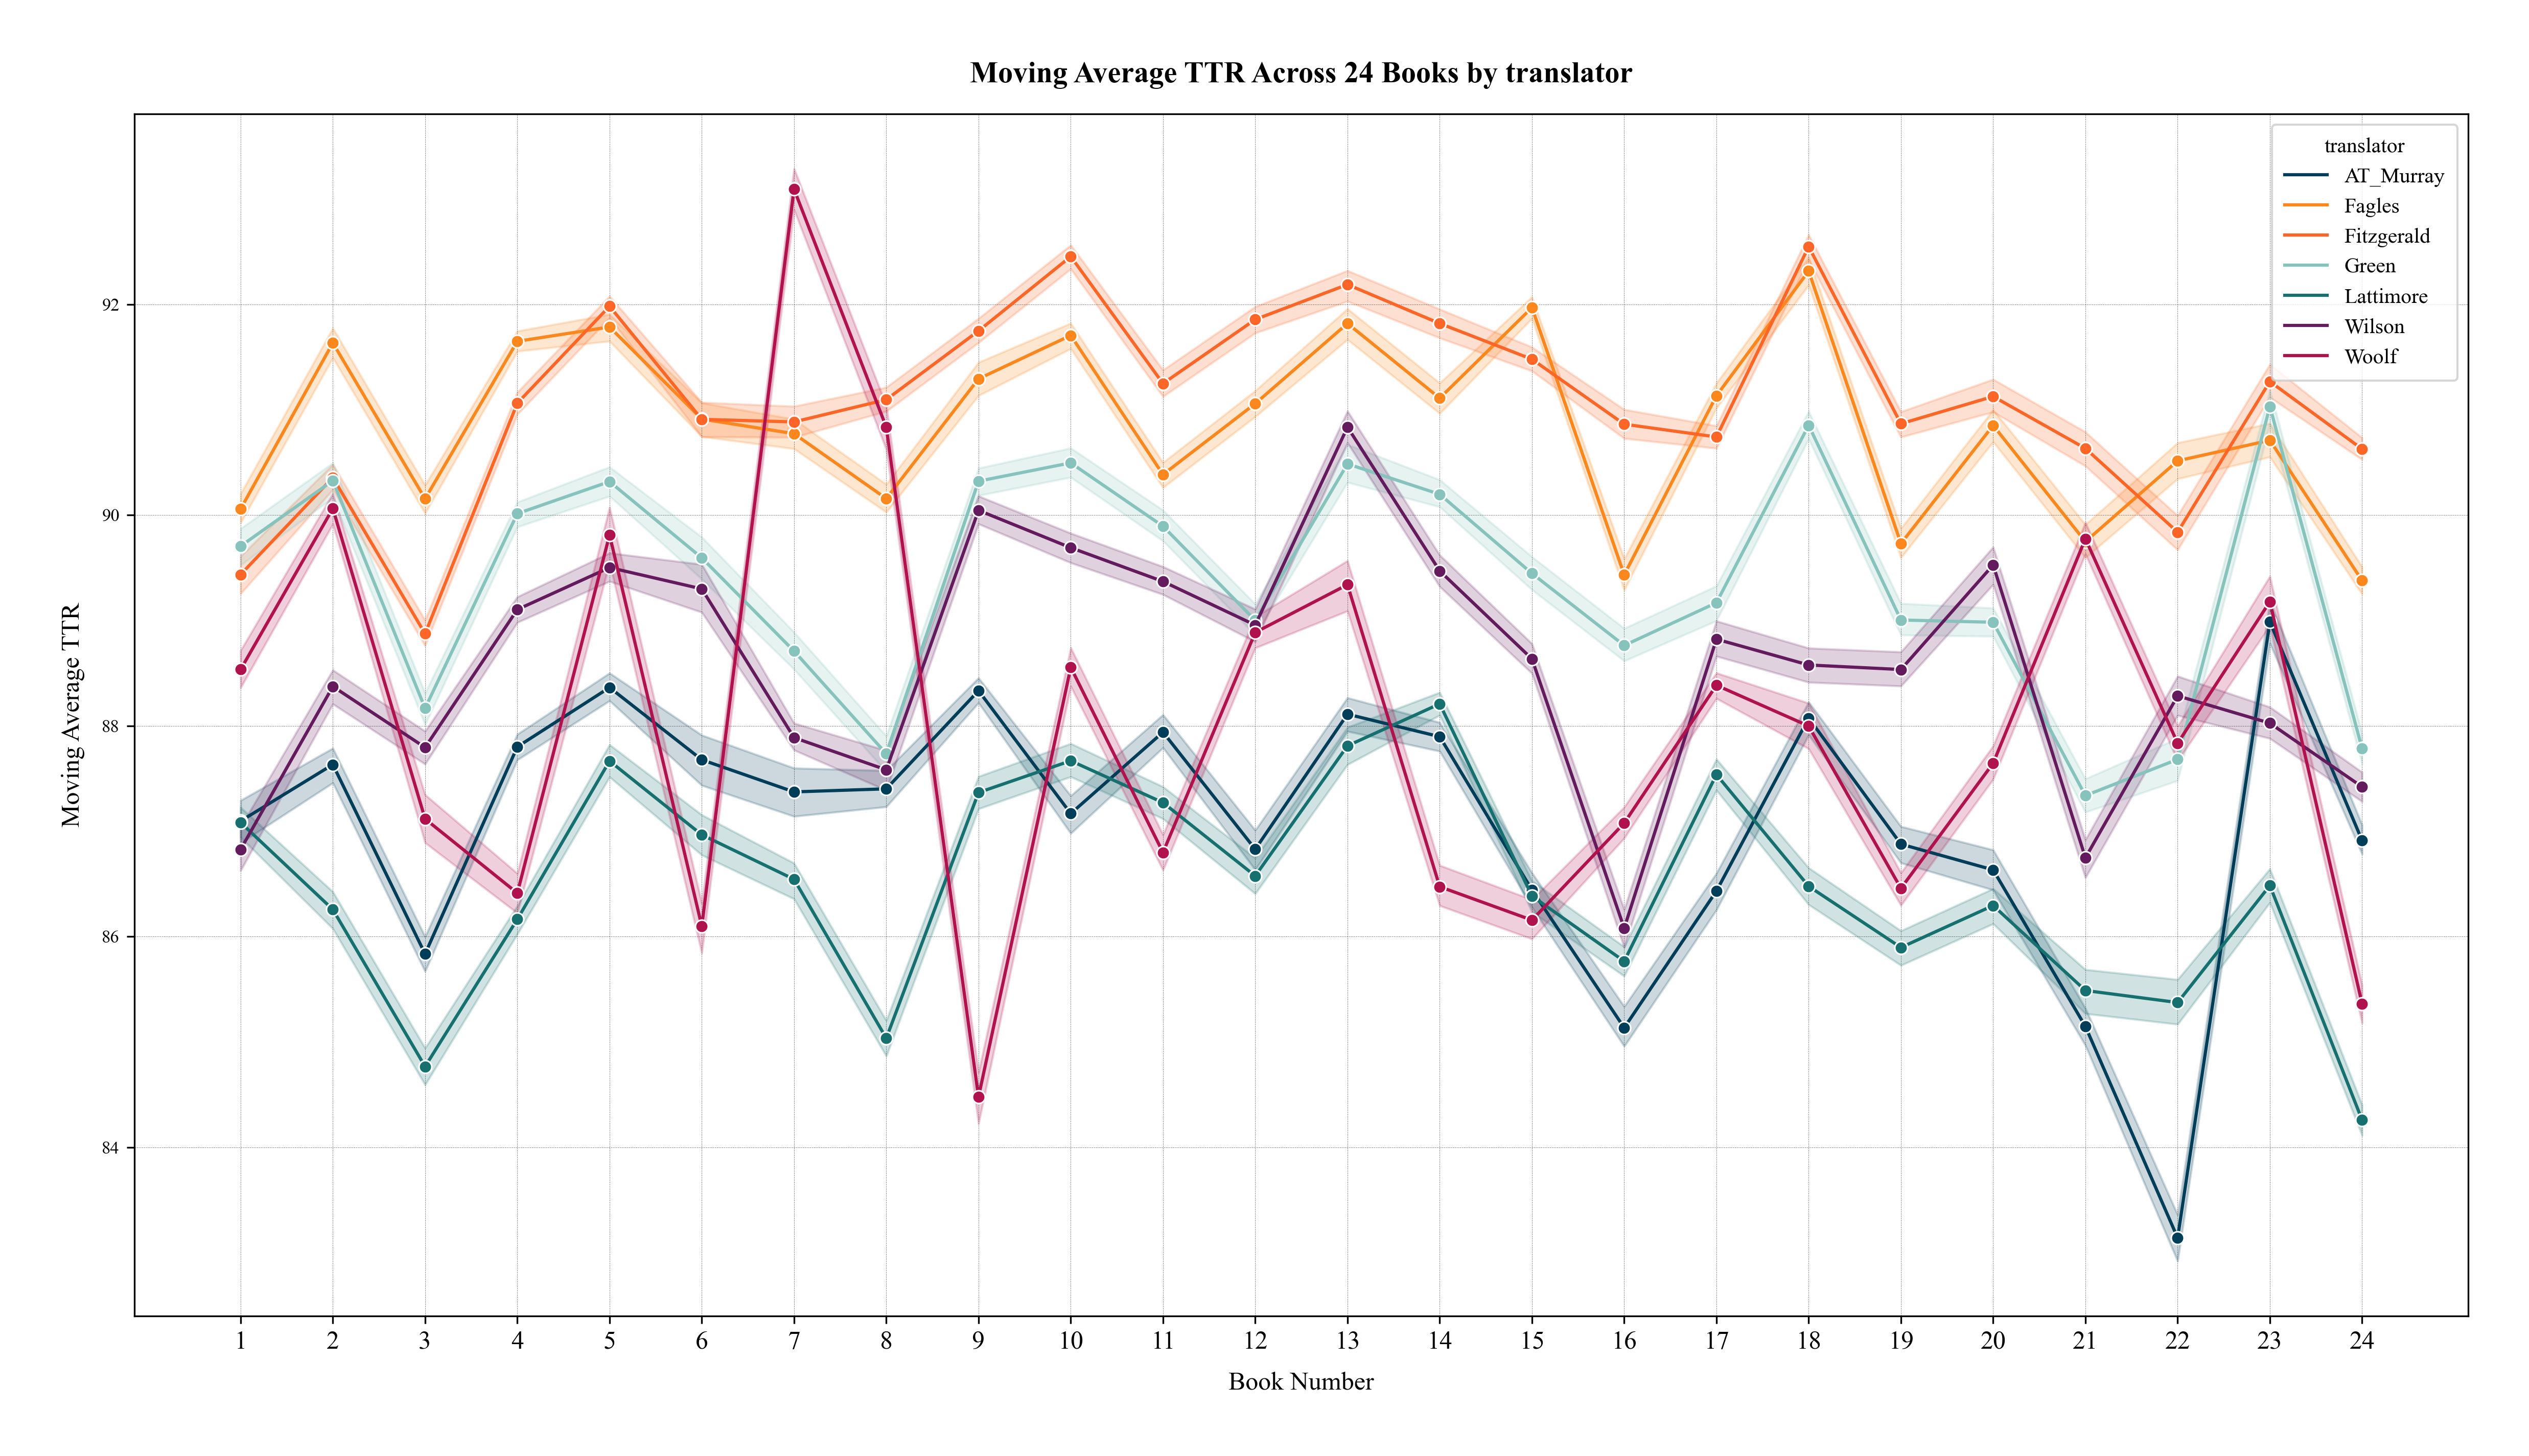

In [23]:
# ----------------------------------------------------------------------
# Plotting Moving-Average TTR
# ----------------------------------------------------------------------

# Explode the 'moving_average_ttr' column if it contains lists
if isinstance(df["moving_average_ttr"].iloc[0], list):  # Check if the column contains lists
    df = df.explode("moving_average_ttr")

# Convert to float (just in case)
df["moving_average_ttr"] = df["moving_average_ttr"].astype(float)

# Sort values by translator and book number to ensure correct order
df = df.sort_values(by=["translator", "book_num"])
plt.figure(figsize=(16, 9))

# Line plot: Moving Average TTR by translator
sns.lineplot(data=df, x="book_num", y="moving_average_ttr", 
             hue="translator", marker="o", palette=palette)

plt.xlabel("Book Number", fontsize=12)
plt.ylabel("Moving Average TTR", fontsize=12)
plt.title("Moving Average TTR Across 24 Books by translator", fontsize=14)
plt.xticks(range(1, 25))  # Ensure x-axis labels from 1 to 24
plt.legend(title="translator")  
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout() 
plt.savefig(output_path_plots + f"moving_average_ttr-{nb_id}.png", dpi=400)
plt.show()

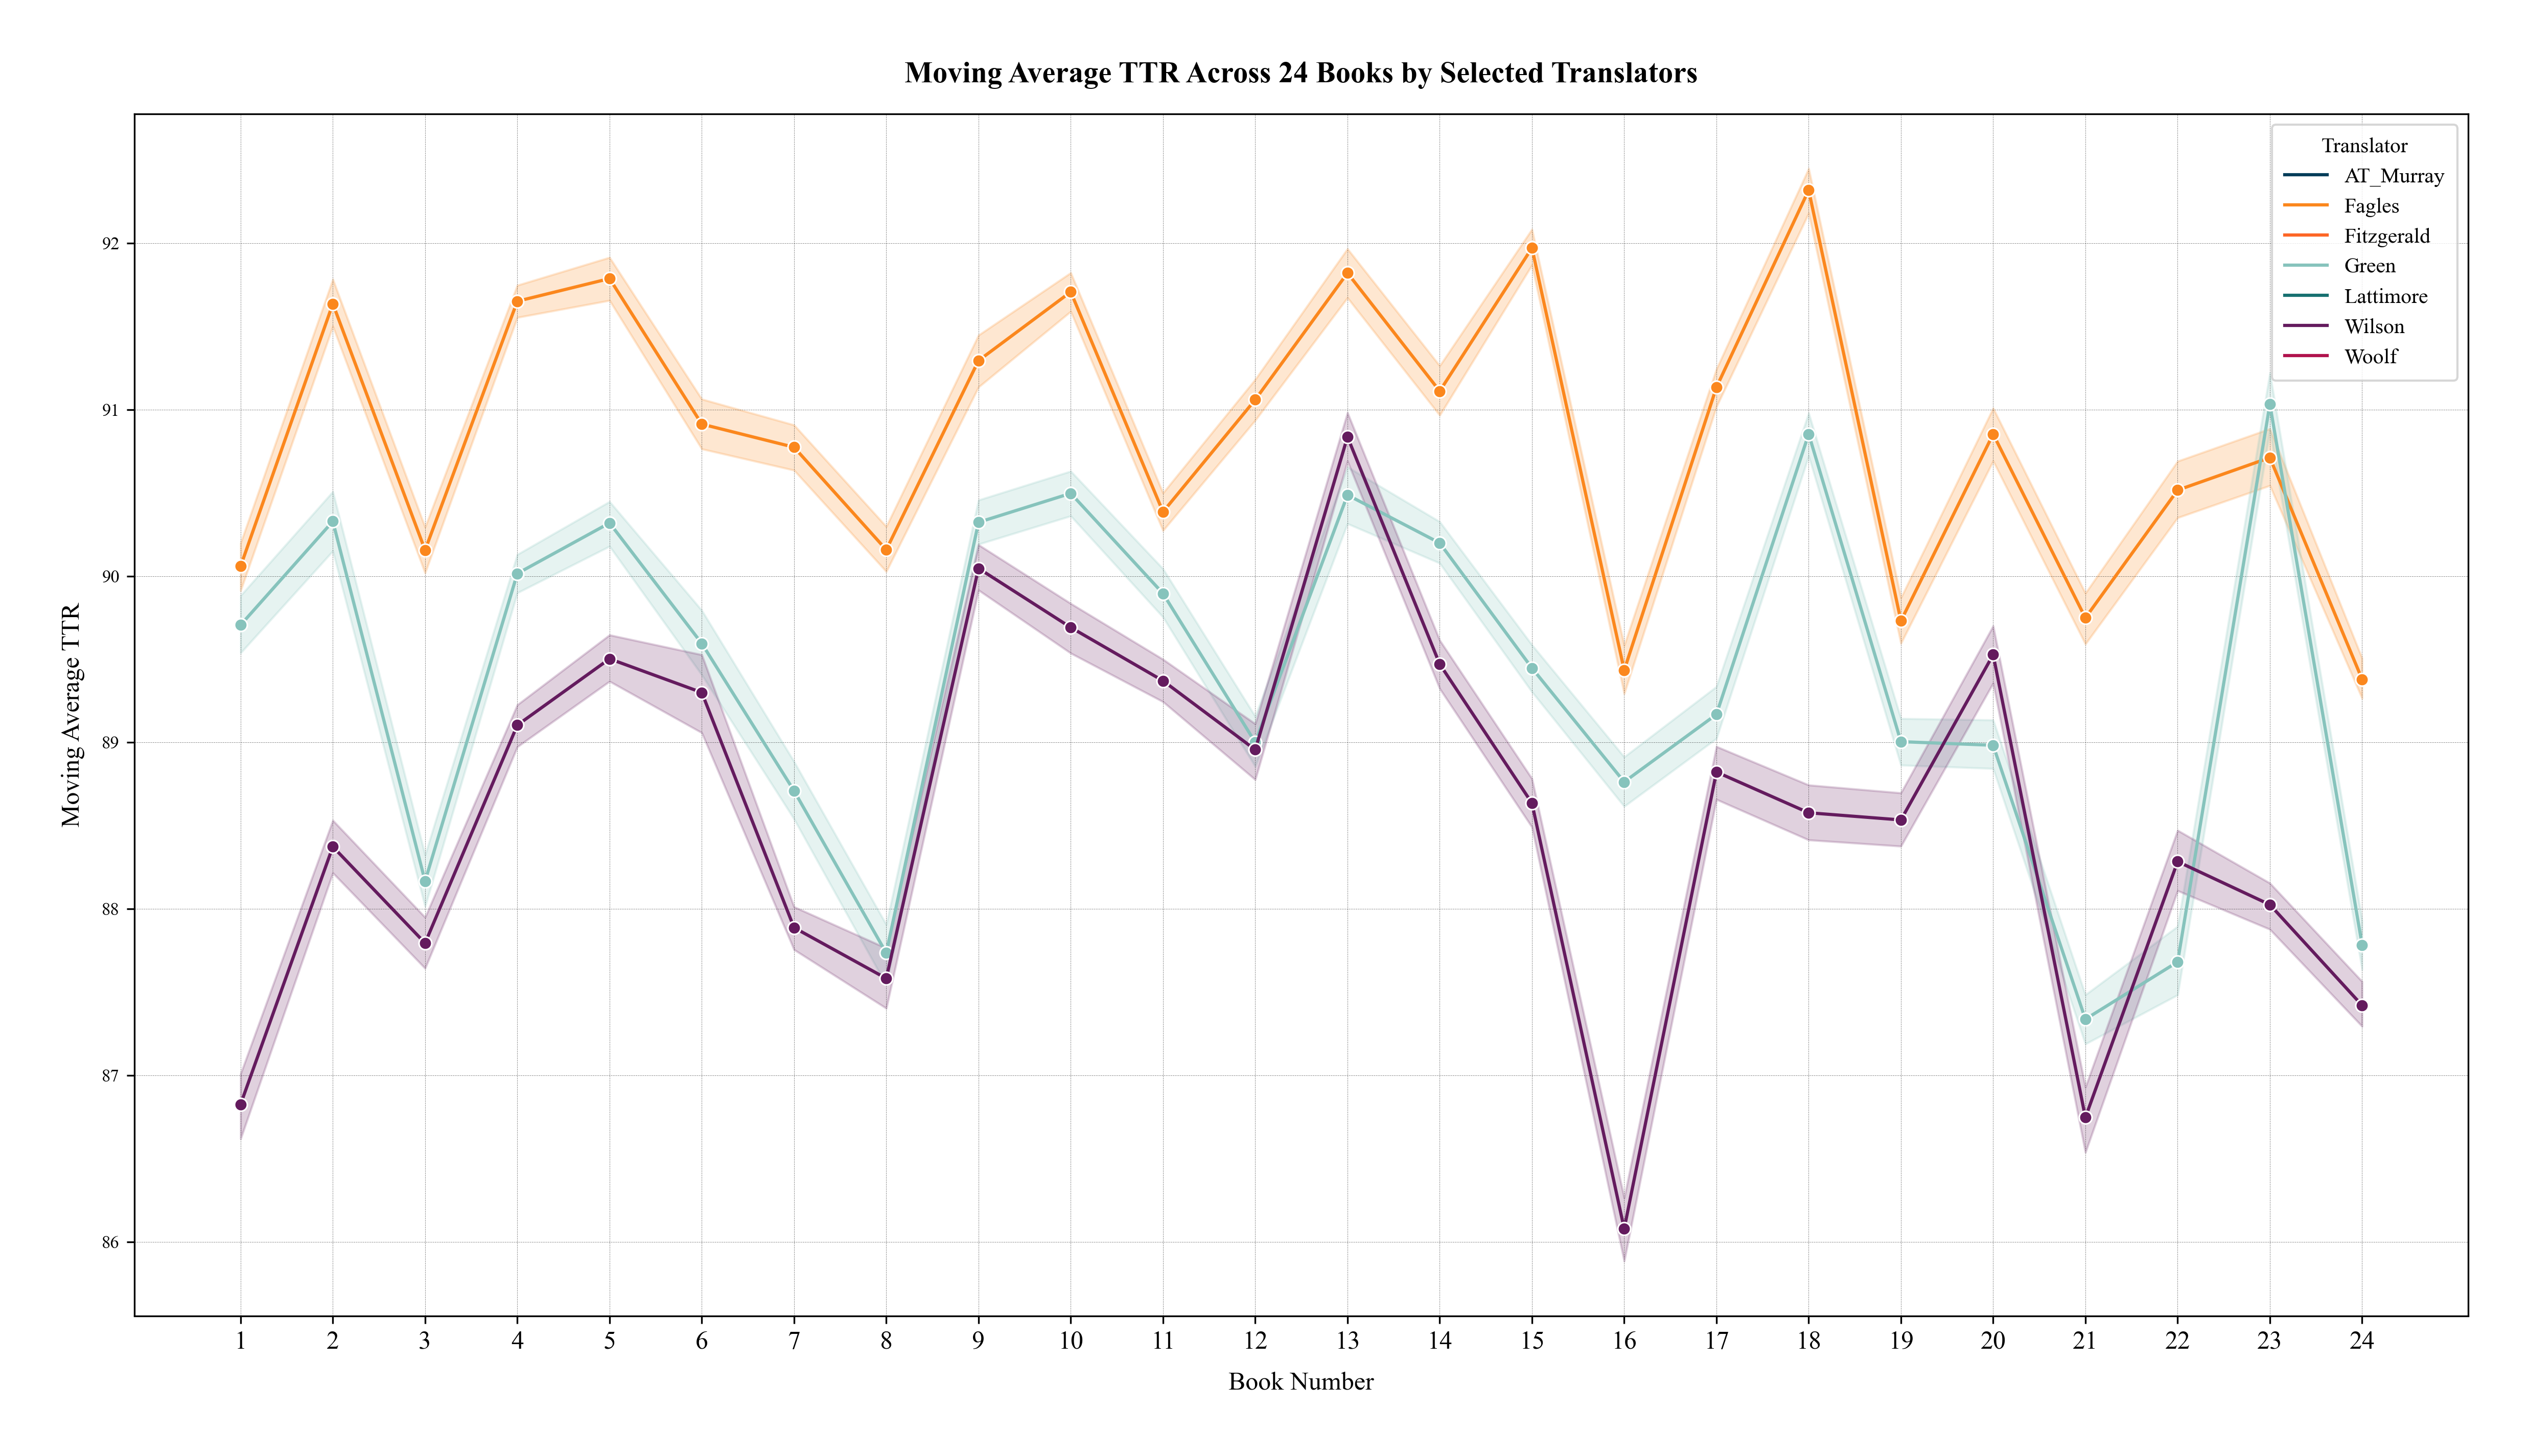

In [24]:
# ----------------------------------------------------------------------
# Plotting Moving-Average TTR
# ----------------------------------------------------------------------
# Subset of translators to include
selected_translators = ['Wilson', 'Fagles', 'Green']

# Create a filtered dataframe with only selected translators
df_subset = df[df['translator'].isin(selected_translators)]

# Explode the 'moving_average_ttr' column if it contains lists
if isinstance(df_subset["moving_average_ttr"].iloc[0], list): # Check if the column contains lists
   df_subset = df_subset.explode("moving_average_ttr")

# Convert to float (just in case)
df_subset["moving_average_ttr"] = df_subset["moving_average_ttr"].astype(float)

# Sort values by translator and book number to ensure correct order
df_subset = df_subset.sort_values(by=["translator", "book_num"])

plt.figure(figsize=(16, 9))

# Line plot: Moving Average TTR by translator
sns.lineplot(data=df_subset, x="book_num", y="moving_average_ttr",
            hue="translator", marker="o", palette=palette)

plt.xlabel("Book Number", fontsize=12)
plt.ylabel("Moving Average TTR", fontsize=12)
plt.title("Moving Average TTR Across 24 Books by Selected Translators", fontsize=14)
plt.xticks(range(1, 25)) # Ensure x-axis labels from 1 to 24
plt.legend(title="Translator")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_path_plots + f"moving_average_ttr_selected_01-{nb_id}.png", dpi=400)
plt.show()

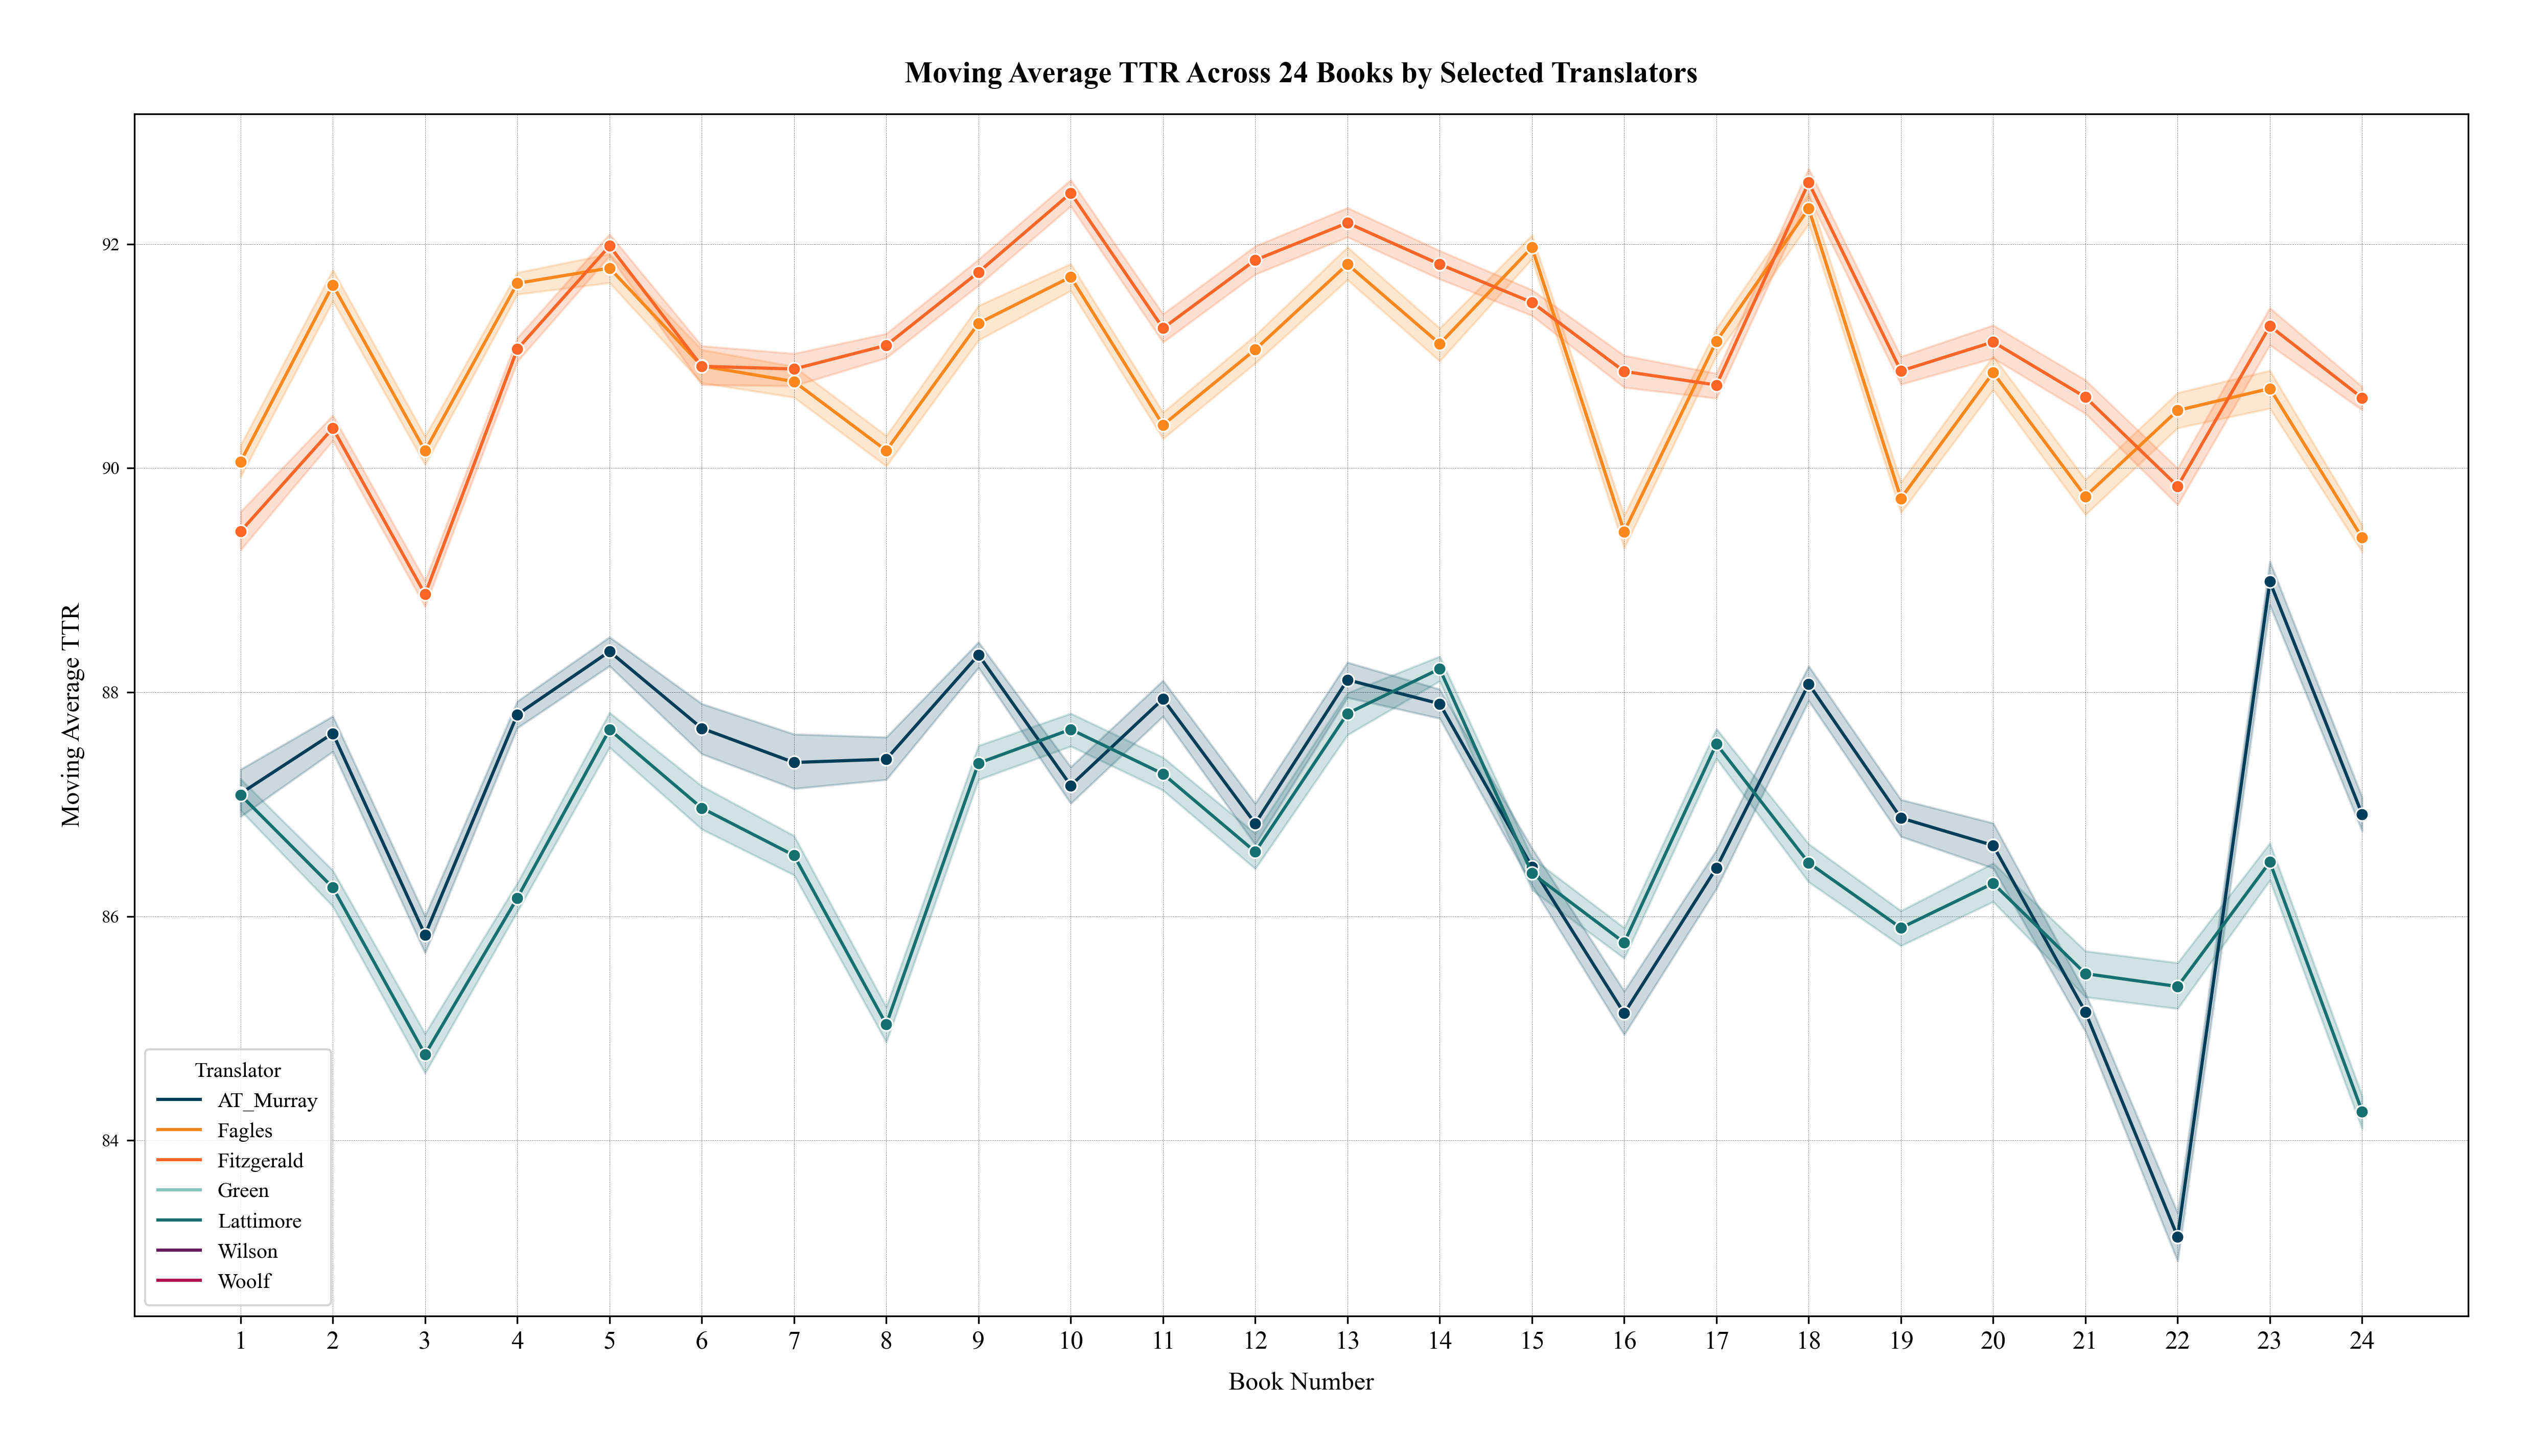

In [25]:
# ----------------------------------------------------------------------
# Plotting Moving-Average TTR
# ----------------------------------------------------------------------
# Subset of translators to include
selected_translators = ['Lattimore', 'Fagles', 'Fitzgerald', 'AT_Murray']

# Create a filtered dataframe with only selected translators
df_subset = df[df['translator'].isin(selected_translators)]

# Explode the 'moving_average_ttr' column if it contains lists
if isinstance(df_subset["moving_average_ttr"].iloc[0], list): # Check if the column contains lists
   df_subset = df_subset.explode("moving_average_ttr")

# Convert to float (just in case)
df_subset["moving_average_ttr"] = df_subset["moving_average_ttr"].astype(float)

# Sort values by translator and book number to ensure correct order
df_subset = df_subset.sort_values(by=["translator", "book_num"])

plt.figure(figsize=(16, 9))

# Line plot: Moving Average TTR by translator
sns.lineplot(data=df_subset, x="book_num", y="moving_average_ttr",
            hue="translator", marker="o", palette=palette)

plt.xlabel("Book Number", fontsize=12)
plt.ylabel("Moving Average TTR", fontsize=12)
plt.title("Moving Average TTR Across 24 Books by Selected Translators", fontsize=14)
plt.xticks(range(1, 25)) # Ensure x-axis labels from 1 to 24
plt.legend(title="Translator")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_path_plots + f"moving_average_ttr_selected_02-{nb_id}.png", dpi=400)
plt.show()

This shows that an author's agency and agenda is more relevant in TTR that time span or coetanity.